# Dubai Real Estate 2025 - Data Cleaning and Validation
This notebook performs a structured cleaning and validation of the pre-filtered residential transactions dataset (transactions_2025.csv).
Each step ensures the dataset adheres to physical, statistical and domain-driven plausibility rules; yielding a complete, internally consistent dataset ready for analysis.

## Main Steps
**- Column Renaming:** Standardized feature names.

**- Type Conversion:** Enforced correct data types for variables.

**- Data Validation:** Confirmed internal consistency between price, size and meter_price.

**- Domain-Based Filtering:** Removed physically impossible property configurations and unrealistic price-per-square-meter values(~1.15% entries removed).

**- Missing Value Imputation:**  
        * Mode imputation for minimal missing values in party count fields.  
        * Median imputation - Units; size-based binning - Villas for missing bedroom numbers.  
        * Mode-by-project imputation for near point of interest features, with remaining nulls replaced by 'Missing'.

**- Room–Size Configuration Cleaning:**  
        * Eliminated implausibly large or small combinations (e.g., Studio > 150 m², 2 B/R < 40 m²).  
        * Verified architectural realism through descriptive and visual inspection. 

**- Export:** The resulting cleaned dataset is saved as re_2025_analysis.csv for analysis and modelling stages.

## Outcome:
The final dataset contains only plausible, complete and analytically stable residential transactions, suitable for exploratory analysis and modeling. A total of 2883 (~1.3%) entries were removed during the process.

# Libraries

In [4]:
import pandas as pd # Data Manipulation
import numpy as np # Data Manipulation

import matplotlib.pyplot as plt # Data Visualization
import seaborn as sns # Data Visualization
sns.set()

# Data

In [9]:
# Loading the pre-filtered Dataset
raw = pd.read_csv('transactions_2025.csv')
df = raw.copy()

In [13]:
df.head(2)

,trans_group_en,instance_date,property_type_en,reg_type_en,area_name_en,project_name_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,Mortgages,2025-09-15,Villa,Existing Properties,Al Mamzer,NaN,Dubai International Airport,Al Qiyadah Metro Station,NaN,NaN,0,7454.35,15000000.0,2012.25,9.0,1.0,0.0
1,Sales,2025-05-27,Villa,Existing Properties,Mirdif,NaN,Dubai International Airport,Etisalat Metro Station,City Centre Mirdif,NaN,0,1520.45,5500000.0,3617.35,1.0,1.0,0.0


# 1. Column Renaming
The name of the columns are changed for easier recognition.

In [16]:
df.columns

Index(['trans_group_en', 'instance_date', 'property_type_en', 'reg_type_en',
       'area_name_en', 'project_name_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'has_parking',
       'procedure_area', 'actual_worth', 'meter_sale_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3'],
      dtype='object')

In [18]:
new_columns = ['transaction_type', 'date', 'property_type',
       'registration', 'area', 'project', 'landmark',
       'metro', 'mall', 'rooms', 'parking', 'size',
       'price', 'meter_price', 'no_sellers', 'no_buyers','no_third_parties'
              ]

In [20]:
df.columns = new_columns

In [22]:
df.head(2)

,transaction_type,date,property_type,registration,area,project,landmark,metro,mall,rooms,parking,size,price,meter_price,no_sellers,no_buyers,no_third_parties
0,Mortgages,2025-09-15,Villa,Existing Properties,Al Mamzer,NaN,Dubai International Airport,Al Qiyadah Metro Station,NaN,NaN,0,7454.35,15000000.0,2012.25,9.0,1.0,0.0
1,Sales,2025-05-27,Villa,Existing Properties,Mirdif,NaN,Dubai International Airport,Etisalat Metro Station,City Centre Mirdif,NaN,0,1520.45,5500000.0,3617.35,1.0,1.0,0.0


# 2. Type Conversion
The number of sellers, buyers and third parties are converted from 'float64' into 'Int64'. This version of integer type accepts conversion of features that include null values.

In [25]:
df['no_sellers'].dtype

dtype('float64')

In [27]:
df['no_sellers'] = df['no_sellers'].astype('Int64')
df['no_buyers'] = df['no_buyers'].astype('Int64')
df['no_third_parties'] = df['no_third_parties'].astype('Int64')

# 3. Data Validation
Confirmed consistency between size, price and meter_price.

In [30]:
# Calculating price per meter
df2 = df.copy()
df2['meter_sale_price'] = (df2['price']/df2['size']).round(2)

# Checking consistency
identical_count = np.isclose(df2['meter_sale_price'], df2['meter_price'], rtol=1e-03, atol=1e-08, equal_nan=True).sum()
print(f"Number of identical entries: {identical_count}")
print(f"Number of total entries: {len(df2)}")

Number of identical entries: 223801
Number of total entries: 223801


# 4. Domain-Based Filtering
Physically impossible or unrealistic property records were removed using domain-informed thresholds derived from Dubai’s residential market characteristics.

**Units:** 25–3000 m² and AED 3000–100000 per m²

**Villas:** 80–7000 m² and AED 3000–100000 per m²

These thresholds ensure analytical validity by excluding erroneous or physically implausible records while preserving legitimate high-value or large properties. Approximately 1.15% of records were removed.

In [33]:
# Size thresholds (m²)
size_min = {'Unit': 25, 'Villa': 80}
size_max = {'Unit': 3000, 'Villa': 7000}

# Price per m² thresholds (AED/m²)
price_m2_min = {'Unit': 3000, 'Villa': 3000}
price_m2_max = {'Unit': 100000, 'Villa': 100000}

# --- Identify invalid entries ---
invalid_mask = (
    ((df['property_type'] == 'Unit') & (
        (df['size'] < size_min['Unit']) |
        (df['size'] > size_max['Unit']) |
        (df['meter_price'] < price_m2_min['Unit']) |
        (df['meter_price'] > price_m2_max['Unit'])
    )) |
    ((df['property_type'] == 'Villa') & (
        (df['size'] < size_min['Villa']) |
        (df['size'] > size_max['Villa']) |
        (df['meter_price'] < price_m2_min['Villa']) |
        (df['meter_price'] > price_m2_max['Villa'])
    ))
)

# --- Create filtered DataFrame ---
df = df.loc[~invalid_mask].copy()

# --- Report removed entries ---
removed = invalid_mask.sum()
print(f"Removed {removed:,} entries ({removed / len(df) * 100:.3f} % of total).")

Removed 2,558 entries (1.156 % of total).


# 5. Missing Values Imputation
Several features lack information. Different imputation methods are applied to each feature depending on their relevance and the number of missing values.

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221243 entries, 1 to 223800
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_type  221243 non-null  object 
 1   date              221243 non-null  object 
 2   property_type     221243 non-null  object 
 3   registration      221243 non-null  object 
 4   area              221243 non-null  object 
 5   project           198164 non-null  object 
 6   landmark          159376 non-null  object 
 7   metro             129558 non-null  object 
 8   mall              126955 non-null  object 
 9   rooms             214846 non-null  object 
 10  parking           221243 non-null  int64  
 11  size              221243 non-null  float64
 12  price             221243 non-null  float64
 13  meter_price       221243 non-null  float64
 14  no_sellers        221206 non-null  Int64  
 15  no_buyers         221206 non-null  Int64  
 16  no_third_parties  221206 

## 5.1. Party-Count Features
'no_sellers', 'no_buyers' and 'no_third_parties' have all the same 37 missing entries (< 0.02 % of the dataset), all corresponding to mortgage transactions for existing Units on 2025-09-15. Since comparable records with identical parameters contain valid data, the missing values are imputed with the modal combination of party counts observed in that segment. This preserves transactional consistency without introducing bias.

In [39]:
# Identify the subset with those features
mask_missing = (
    (df['transaction_type'] == 'Mortgages') &
    (df['registration'] == 'Existing Properties') &
    (df['property_type'] == 'Unit')
)

# Compute modal values from valid rows with the same characteristics
mode_values = (
    df.loc[mask_missing & df['no_buyers'].notna(), 
           ['no_sellers', 'no_buyers', 'no_third_parties']]
    .mode()
    .iloc[0]
)

# Fill missing values
df.loc[mask_missing, ['no_sellers', 'no_buyers', 'no_third_parties']] = (
    df.loc[mask_missing, ['no_sellers', 'no_buyers', 'no_third_parties']]
    .fillna(mode_values)
)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221243 entries, 1 to 223800
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_type  221243 non-null  object 
 1   date              221243 non-null  object 
 2   property_type     221243 non-null  object 
 3   registration      221243 non-null  object 
 4   area              221243 non-null  object 
 5   project           198164 non-null  object 
 6   landmark          159376 non-null  object 
 7   metro             129558 non-null  object 
 8   mall              126955 non-null  object 
 9   rooms             214846 non-null  object 
 10  parking           221243 non-null  int64  
 11  size              221243 non-null  float64
 12  price             221243 non-null  float64
 13  meter_price       221243 non-null  float64
 14  no_sellers        221243 non-null  Int64  
 15  no_buyers         221243 non-null  Int64  
 16  no_third_parties  221243 

## 5.2. Number of Bedrooms
A total of 6397 records have missing rooms information. Notably, only 12 of these correspond to Units, despite Units representing the majority of all transactions. This asymmetry indicates that the 'number of rooms' attribute is far more consistently recorded for Units than for Villas.

In practice, apartment listings rely heavily on bedroom count as a key differentiator to distinct market segments and user profiles (e.g. studios/1BR apartments for singles or couples, more bedrooms for bigger families). Villas, in contrast, inherently accomodate multiple bedrooms, and their size alone already implies capacity. This likely explains the higer rate of missing room data among villas and suggests that missingness is systematic rather than random, arising from recording conventions rather than data corruption.

In [44]:
df[df['rooms'].isnull()]['property_type'].value_counts()

property_type
Villa    6385
Unit       12
Name: count, dtype: int64

In [46]:
df['property_type'].value_counts()

property_type
Unit     194727
Villa     26516
Name: count, dtype: int64

### 5.2.1. Units
Twelve Unit records lack bedroom information (< 0.01 % of all Units). Given their minimal impact and the ordinal nature of the variable, median floor areas are computed for each bedroom category (Penthouses excluded given their especial nature) across all Units, and missing records are assigned the category whose median size is closest to their own. This approach provides a simple, interpretable and statistically robust imputation while maintaining overall dataset consistency.

Additionally, three entries catalogued as 'shop' were directly removed since this project focuses on residential properties.

In [49]:
df[df['property_type']=='Unit']['rooms'].value_counts(dropna=False)

rooms
1 B/R        85699
2 B/R        49424
Studio       45100
3 B/R        12725
4 B/R         1435
5 B/R          208
PENTHOUSE       94
6 B/R           26
NaN             12
Shop             3
7 B/R            1
Name: count, dtype: int64

In [51]:
# Removing the 3 entries catalogued as 'Shop' (non-residential)
df = df[df['rooms']!="Shop"]

In [53]:
# Filtering only Units with known room counts
units_with_rooms = df[(df['property_type'] == 'Unit') & (df['rooms'].notna()) & (df['rooms']!='PENTHOUSE')].copy()

# Computing median size per bedroom count
unit_size_map = units_with_rooms.groupby('rooms')['size'].median().sort_index()

# Identifying Units with missing room data
mask_units_missing = (df['property_type'] == 'Unit') & (df['rooms'].isna())

# For each missing Unit, finding the closest room category by size
for idx, row in df.loc[mask_units_missing].iterrows():
    diffs = (unit_size_map - row['size']).abs()
    df.at[idx, 'rooms'] = diffs.idxmin()

In [55]:
df[df['property_type']=='Unit']['rooms'].value_counts(dropna=False)

rooms
1 B/R        85702
2 B/R        49427
Studio       45101
3 B/R        12729
4 B/R         1436
5 B/R          208
PENTHOUSE       94
6 B/R           26
7 B/R            1
Name: count, dtype: int64

In [57]:
# Verification of imputed units
imputed_units = df[(df['property_type'] == 'Unit') & (df.index.isin(mask_units_missing[mask_units_missing].index))]

imputed_units[['size','rooms']]

,size,rooms
15977,109.14,2 B/R
19815,130.99,2 B/R
37498,234.86,3 B/R
102885,66.98,1 B/R
141853,207.65,3 B/R
173239,209.70,3 B/R
173798,234.86,3 B/R
180211,81.47,1 B/R
189939,66.98,1 B/R
197646,415.30,4 B/R


### 5.2.2. Villas
In contrast to units, rooms missingness among villas (~25%) is substantial and therefore requires a more deliberate approach balancing statistical rigor, interpretability and computational simplicity.

For the initial exploratory phase, a size-based median imputation is applied, assigning missing bedroom counts according to the median value observed among villas of comparable floor area. This approach preserves interpretability and is appropriate for exploratory analysis.

In subsequent modelling stages, more sophisticated methods such as K-Nearest Neighbours or regression-based imputation will be tested to assess whether they improve predictive accuracy or provide additional structural insight.

In [61]:
df[df['property_type']=='Villa']['rooms'].value_counts(dropna=False)

rooms
3 B/R    9830
4 B/R    7583
NaN      6385
2 B/R    1746
5 B/R     853
1 B/R      57
6 B/R      46
7 B/R      16
Name: count, dtype: int64

In order to perform the described approach, the values of rooms need to be converted to integers to calculate medians. Once the values have been imputed, they are reconverted back to the original state. While for modelling they might potentially be encoded again, it is interesting to keep them like this during the exploratory analysis to maintain clarity (i.e. studios and penthouses).

In [64]:
# Dictionary to convert rooms to integers
bedroom_map = {
    '1 B/R': 1,
    '2 B/R': 2,
    '3 B/R': 3,
    '4 B/R': 4,
    '5 B/R': 5,
    '6 B/R': 6,
    '7 B/R': 7
}

# Inverted dictionary to return to original values
inverted_bedroom_map = dict(zip(bedroom_map.values(), bedroom_map.keys()))

In [66]:
# Filtering only villas
villas = df[df['property_type'] == 'Villa'].copy()

In [68]:
# Creating a new df to check how the missing values were assigned
rooms_check = villas['rooms'].value_counts(dropna=False).to_frame()

In [70]:
# Performing the imputation

# Creating size bins
bins = [0, 200, 400, 600, 800, 1000, 1500, 2000, 7000]
labels = ['<200', '200-400', '400-600', '600-800', '800-1000', '1000-1500', '1500-2000', '2000+']
villas['size_bin'] = pd.cut(villas['size'], bins=bins, labels=labels, right=False)

# Computing median rooms per bin
villas['rooms'] = villas['rooms'].map(bedroom_map).astype('Int64')
bin_medians = villas.groupby('size_bin', observed=False)['rooms'].median()

# Impute missing values with corresponding bin median
mask_missing_villas = villas['rooms'].isna()
villas.loc[mask_missing_villas, 'rooms'] = villas.loc[mask_missing_villas, 'size_bin'].map(bin_medians)

# Returning to original formatting and checking results
villas['rooms'] = villas['rooms'].map(inverted_bedroom_map)
rooms_check['post_imputation'] = villas['rooms'].value_counts(dropna=False)

It can be observed that the missing values were mostly imputed as 4 and 5 B/R. A couple of hundreds were considered 3 or 6 B/R, whereas 1,2 and 7 B/R were untouched. These results make sense from a logical perspective, with most villas being generally multi-bedroom homes, and villas with less than 3 (or more than 6) rooms are just exceptions.

In [73]:
rooms_check

,count,post_imputation
rooms,,
3 B/R,9830,10293.0
4 B/R,7583,11555.0
NaN,6385,NaN
2 B/R,1746,1746.0
5 B/R,853,2578.0
1 B/R,57,57.0
6 B/R,46,271.0
7 B/R,16,16.0


In [75]:
# Merge imputed villas back into main dataframe
df.update(villas[['rooms']])

In [77]:
df['rooms'].value_counts(dropna=False)

rooms
1 B/R        85759
2 B/R        51173
Studio       45101
3 B/R        23022
4 B/R        12991
5 B/R         2786
6 B/R          297
PENTHOUSE       94
7 B/R           17
Name: count, dtype: int64

## 5.3. Near Point of Interest Features
There are three features in this dataset with information about near points of interest: 'landmark', 'metro' and 'mall'. These features contain between 25% and 50% missing values. All of them will be treated equally in terms of the approach on how to deal with their missing values, and the features will be called as Point of Interst (PoI).

Instead of using 'area' for imputation - communities in Dubai can be fairly large leading to many potential wrong assignments - the 'project' feature is used for imputation - it is safe to assume that all properties under a same project should be fairly close to each other. However, some entries under the same project have different PoI recorded. This could be due to errors or perhaps to buildings having several nearest PoI, hence the different registrations. To stay on the safe side, the imputation is done with the most common one under the same project.

This approach fixes anyway only 1% of the missing values. To be able to keep these features for future analysis without filling them with potentially wrong information, all the rest null values are filled as 'Missing'.

In [80]:
# List of columns to fill
cols = ['landmark', 'metro', 'mall']

# Fill missing values per project with the most frequent value (mode) in that project
for col in cols:
    df[col] = df[col].fillna(df.groupby('project')[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA))

# Fill remaining missing values with 'None' for all three columns
df[cols] = df[cols].fillna('Missing')

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221240 entries, 1 to 223800
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_type  221240 non-null  object 
 1   date              221240 non-null  object 
 2   property_type     221240 non-null  object 
 3   registration      221240 non-null  object 
 4   area              221240 non-null  object 
 5   project           198164 non-null  object 
 6   landmark          221240 non-null  object 
 7   metro             221240 non-null  object 
 8   mall              221240 non-null  object 
 9   rooms             221240 non-null  object 
 10  parking           221240 non-null  int64  
 11  size              221240 non-null  float64
 12  price             221240 non-null  float64
 13  meter_price       221240 non-null  float64
 14  no_sellers        221240 non-null  Int64  
 15  no_buyers         221240 non-null  Int64  
 16  no_third_parties  221240 

## 5.4. Project
The project column is mainly used as an imputation source for other missing values. We will therefore just fill the own project missing values with 'Missing'.

Additionally, in subsequent stages of the project, this feature will be used to try to extract the developers name, which could provide predictive value in future modelling stages.

In [84]:
df['project'] = df['project'].fillna('Missing')

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221240 entries, 1 to 223800
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_type  221240 non-null  object 
 1   date              221240 non-null  object 
 2   property_type     221240 non-null  object 
 3   registration      221240 non-null  object 
 4   area              221240 non-null  object 
 5   project           221240 non-null  object 
 6   landmark          221240 non-null  object 
 7   metro             221240 non-null  object 
 8   mall              221240 non-null  object 
 9   rooms             221240 non-null  object 
 10  parking           221240 non-null  int64  
 11  size              221240 non-null  float64
 12  price             221240 non-null  float64
 13  meter_price       221240 non-null  float64
 14  no_sellers        221240 non-null  Int64  
 15  no_buyers         221240 non-null  Int64  
 16  no_third_parties  221240 

# 6. Room-Size Configurations Cleaning
Following the imputation of missing room counts and removal of implausible size or price entries, a final inspection is conducted to identify physically unrealistic combinations between the number of bedrooms and floor area. These configurations are assessed through visual and statistical inspection to ensure that all remaining observations represent feasible layouts.

In [89]:
# Descriptive statistics of room configurations
(df.groupby('rooms')['size']).describe()

,count,mean,std,min,25%,50%,75%,max
rooms,,,,,,,,
1 B/R,85759.0,74.367823,28.567042,25.06,66.0900,72.600,80.5100,2736.91
2 B/R,51173.0,122.899348,39.800943,25.07,103.4000,117.120,135.1600,4852.83
3 B/R,23022.0,194.296402,70.084357,28.40,153.6525,175.165,206.9300,1301.56
4 B/R,12991.0,394.588318,266.809135,45.64,245.6150,300.000,426.9800,1636.64
5 B/R,2786.0,598.523715,207.533679,74.99,448.2375,635.590,705.9075,2902.46
6 B/R,297.0,2087.332525,1171.841426,226.57,1525.2800,1858.060,2583.7300,6967.73
7 B/R,17.0,1568.555294,1057.604470,960.00,1098.6300,1144.500,1696.2400,5395.97
PENTHOUSE,94.0,300.299255,152.427731,98.39,194.8600,229.580,410.9800,1035.14
Studio,45101.0,39.994637,6.559109,25.09,35.6800,39.040,42.9900,225.38


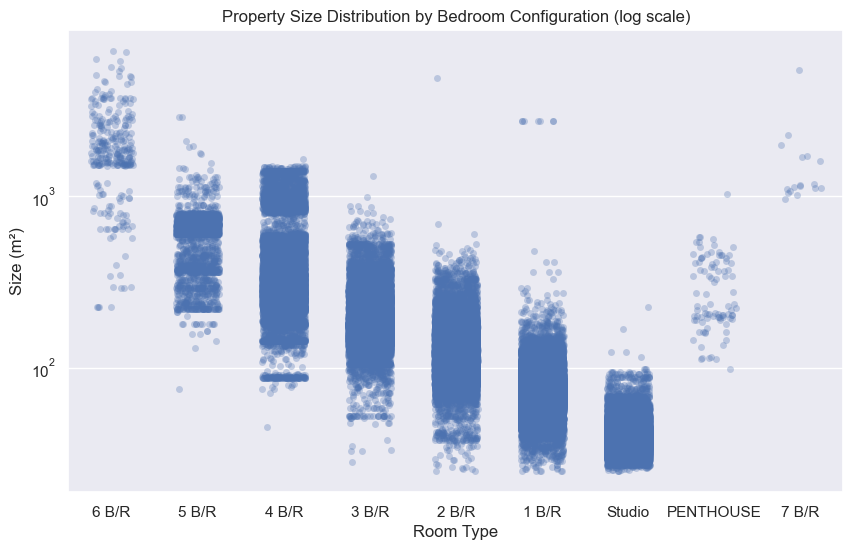

In [91]:
# Visual Distribution
plt.figure(figsize=(10,6))
sns.stripplot(data=df, x='rooms', y='size', alpha=0.3, jitter=0.25)
plt.yscale('log')  # log scale to compress extreme outliers
plt.title("Property Size Distribution by Bedroom Configuration (log scale)")
plt.xlabel("Room Type")
plt.ylabel("Size (m²)")
plt.show()

## 6.1. Overly Large Room-Size Configuration
A manual inspection of size distributions revealed several physically unrealistic combinations. Examples included studios over 150 m², 1-bedroom apartments above 400 m², and 2-bedroom units exceeding 700 m².

These cases are inconsistent with Dubai market standards and with other properties within the same projects, likely arising from data-entry or classification errors.

To preserve the analytical validity of subsequent size–price relationships and prevent bias in descriptive or predictive models, these implausible records were removed.

In [94]:
# Keep only plausible entries based on room-size rules
suspicious_big_df = df[
    ((df['rooms'] == 'Studio') & (df['size'] > 150)) |
    ((df['rooms'] == '1 B/R') & (df['size'] > 400)) |
    ((df['rooms'] == '2 B/R') & (df['size'] > 700))
]

print(f"Removed {len(suspicious_big_df)} implausible records.")
df = df.drop(suspicious_big_df.index).reset_index(drop=True)


Removed 13 implausible records.


This step eliminated only a very small share of total entries but ensured a cleaner and more realistic dataset.

## 6.2. Unrealistically Small Room-Size Configurations
Plenty of entries were also identified with abnormally small floor areas relative to their bedroom count. While some very compact dwellings are plausible, thresholds are selected conservatively based on architectural feasibility to eliminate only the clearly impossible configurations.
All entries below these standards are removed to maintain analytical consistency without erasing genuine small-unit variation.

In [98]:
# Keep only plausible entries based on room-size rules
suspicious_small_df = df[
    ((df['rooms'] == '1 B/R') & (df['size'] < 25))  |
    ((df['rooms'] == '2 B/R') & (df['size'] < 40))  |
    ((df['rooms'] == '3 B/R') & (df['size'] < 70))  |
    ((df['rooms'] == '4 B/R') & (df['size'] < 100)) |
    ((df['rooms'] == '5 B/R') & (df['size'] < 130)) |
    ((df['rooms'] == '6 B/R') & (df['size'] < 170)) 
]

print(f"Removed {len(suspicious_small_df)} implausible records.")
df = df.drop(suspicious_small_df.index).reset_index(drop=True)


Removed 309 implausible records.


Together, these size-room consistency checks eliminated a neglictible fraction of total entries (<0.2%) but substantially improved the dataset's internal coherence and interpretive reliability.

# 7. Final Check and Export

In [102]:
# No missing data verification
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220918 entries, 0 to 220917
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_type  220918 non-null  object 
 1   date              220918 non-null  object 
 2   property_type     220918 non-null  object 
 3   registration      220918 non-null  object 
 4   area              220918 non-null  object 
 5   project           220918 non-null  object 
 6   landmark          220918 non-null  object 
 7   metro             220918 non-null  object 
 8   mall              220918 non-null  object 
 9   rooms             220918 non-null  object 
 10  parking           220918 non-null  int64  
 11  size              220918 non-null  float64
 12  price             220918 non-null  float64
 13  meter_price       220918 non-null  float64
 14  no_sellers        220918 non-null  Int64  
 15  no_buyers         220918 non-null  Int64  
 16  no_third_parties  22

In [104]:
# Counts
initial = len(raw)
final = len(df)
removed = initial - final
removed_pct = removed/initial*100

# Summary
# Display dynamic summary
print("=== DATA SUMMARY ===")
print(f"Initial record count: {initial:,}")
print(f"Final record count:   {final}")
print(f"Records removed:      {removed:,} ({removed_pct:.2f}%)\n")

=== DATA SUMMARY ===
Initial record count: 223,801
Final record count:   220918
Records removed:      2,883 (1.29%)



In [112]:
# Exporting the dataset
df.to_csv('re_2025_analysis.csv', index=False)